#  Previsão de Preço de Veículos Usados no Brasil

> ⚠️ **Este conteúdo é destinado apenas para fins educacionais. Os dados exibidos são ilustrativos e podem não corresponder a situações reais.**

---

## Metodologia: CRISP-DM

| Fase | Descrição |
|---|---|
| 1️⃣ Entendimento do Negócio | Prever o valor de venda de veículos usados no Brasil |
| 2️⃣ Entendimento dos Dados | Análise Exploratória (EDA) |
| 3️⃣ Preparação dos Dados | Limpeza, imputação, feature engineering, encoding |
| 4️⃣ Modelagem | Comparação de 7 algoritmos de regressão |
| 5️⃣ Avaliação | Métricas + rastreamento com MLflow |
| 6️⃣ Implantação | Deploy no Hugging Face Spaces via Gradio |

**Dataset:** 10.000 registros de veículos usados  
**Variável alvo:** `Valor_Venda` (R$)

---
## 0. Instalação de Dependências

In [1]:
# Instalar dependências necessárias
!pip install pandas numpy scikit-learn xgboost lightgbm mlflow matplotlib seaborn joblib gradio --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.1/197.1 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 17.8 MB/s eta 0:00:00


---
## 1. Imports e Configurações

In [2]:
import os
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns

import mlflow
import mlflow.sklearn

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
)
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Diretórios de saída
os.makedirs('eda_outputs', exist_ok=True)
os.makedirs('models', exist_ok=True)

print(' Imports concluídos com sucesso!')
print(f'   pandas  {pd.__version__}')
print(f'   numpy   {np.__version__}')
print(f'   sklearn importado')
print(f'   mlflow  {mlflow.__version__}')

 Imports concluídos com sucesso!
   pandas  2.2.2
   numpy   2.0.2
   sklearn importado
   mlflow  3.10.1


---
## 2. Fase 1 & 2: Entendimento do Negócio e dos Dados

### 2.1 Carregamento e Visão Geral

In [3]:
# Carregar dataset
# Ajuste o caminho conforme necessário
DATA_PATH = 'dataset_carros_brasil.csv'

df_raw = pd.read_csv(DATA_PATH)

print('=' * 60)
print('VISÃO GERAL DO DATASET')
print('=' * 60)
print(f'Linhas:   {df_raw.shape[0]:,}')
print(f'Colunas:  {df_raw.shape[1]}')

df_raw.head()

VISÃO GERAL DO DATASET
Linhas:   10,000
Colunas:  9


,Marca,Modelo,Ano,Quilometragem,Cor,Cambio,Combustivel,Portas,Valor_Venda
0,Ford,EcoSport,2003.0,82624,Azul,Automático,Flex,4,52604.2
1,Hyundai,HB20S,2017.0,69260,Azul,Automático,Diesel,2,63219.0
2,Jeep,Renegade,2008.0,106493,Cinza,Manual,Gasolina,2,79710.4
3,Toyota,Corolla,2018.0,53570,Prata,Automático,Flex,2,99149.0
4,Ford,Ranger,2009.0,21643,Prata,Manual,Flex,2,68913.4


In [4]:
# Tipos de dados e valores nulos
info = pd.DataFrame({
    'Tipo'     : df_raw.dtypes,
    'Nulos'    : df_raw.isnull().sum(),
    '% Nulos'  : (df_raw.isnull().mean() * 100).round(2),
    'Únicos'   : df_raw.nunique(),
})
print('\n--- Tipos, Nulos e Cardinalidade ---')
display(info)


--- Tipos, Nulos e Cardinalidade ---


,Tipo,Nulos,% Nulos,Únicos
Marca,object,0,0.0,10
Modelo,object,0,0.0,32
Ano,float64,100,1.0,24
Quilometragem,object,0,0.0,9653
Cor,object,0,0.0,6
Cambio,object,0,0.0,2
Combustivel,object,0,0.0,3
Portas,int64,0,0.0,2
Valor_Venda,float64,0,0.0,9672


In [5]:
# Estatísticas descritivas
print('--- Estatísticas Numéricas ---')
display(df_raw.describe().T)

--- Estatísticas Numéricas ---


,count,mean,std,min,25%,50%,75%,max
Ano,9900.0,2011.516061,6.903872,2000.0,2006.00,2012.0,2017.0,2023.0
Portas,10000.0,3.008600,1.000013,2.0,2.00,4.0,4.0,4.0
Valor_Venda,10000.0,83097.486840,166858.222134,10000.0,44467.05,58905.7,74804.4,1241962.0


In [6]:
# Frequência das variáveis categóricas
cat_cols = ['Marca', 'Modelo', 'Cor', 'Cambio', 'Combustivel']

for col in cat_cols:
    print(f'\n▶ {col}:')
    print(df_raw[col].value_counts().to_string())


▶ Marca:
Marca
Volkswagen    1053
Nissan        1034
Honda         1021
Ford          1017
Fiat           996
Renault        994
Chevrolet      985
Hyundai        971
Jeep           967
Toyota         962

▶ Modelo:
Modelo
Compass      493
Renegade     474
Frontier     363
Kicks        358
Duster       355
EcoSport     354
Civic        343
HR-V         342
Ranger       339
Fit          336
HB20S        327
Corolla      327
Creta        324
Ka           324
Kwid         321
Hilux        321
HB20         320
Sandero      318
Yaris        314
Versa        313
Polo         276
Cronos       275
Onix Plus    268
T-Cross      267
Mobi         260
Virtus       256
Gol          254
Tracker      240
S10          239
Argo         239
Onix         238
Toro         222

▶ Cor:
Cor
Azul        1739
Cinza       1720
Preto       1700
Branco      1652
Vermelho    1599
Prata       1590

▶ Cambio:
Cambio
Automático    5051
Manual        4949

▶ Combustivel:
Combustivel
Flex        3353
Diesel      3328


### 2.2 Análise Exploratória de Dados (EDA)

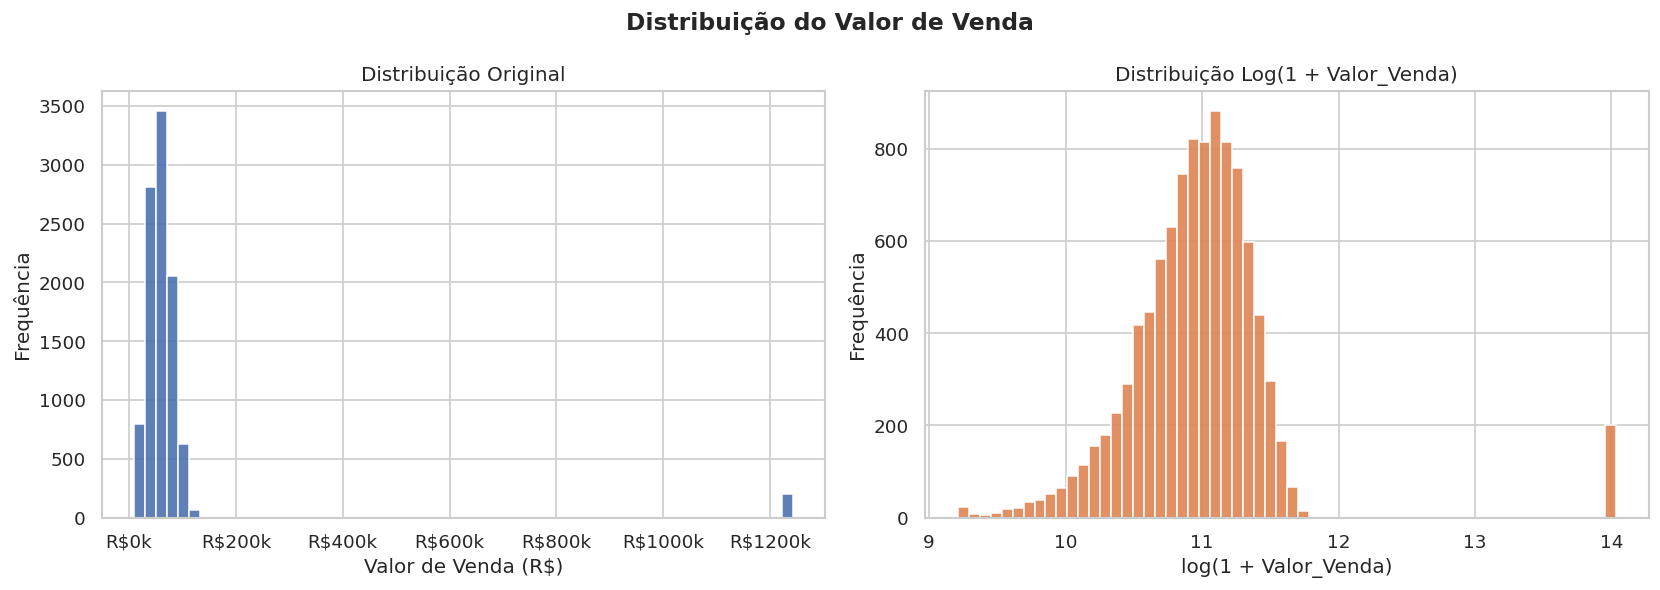

In [7]:
# ── Gráfico 1: Distribuição da variável alvo ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuição do Valor de Venda', fontsize=14, fontweight='bold')

axes[0].hist(df_raw['Valor_Venda'], bins=60, color='#4C72B0', edgecolor='white', alpha=0.9)
axes[0].set_title('Distribuição Original')
axes[0].set_xlabel('Valor de Venda (R$)')
axes[0].set_ylabel('Frequência')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))

log_vals = np.log1p(df_raw['Valor_Venda'])
axes[1].hist(log_vals, bins=60, color='#DD8452', edgecolor='white', alpha=0.9)
axes[1].set_title('Distribuição Log(1 + Valor_Venda)')
axes[1].set_xlabel('log(1 + Valor_Venda)')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.savefig('eda_outputs/01_distribuicao_alvo.png')
plt.show()

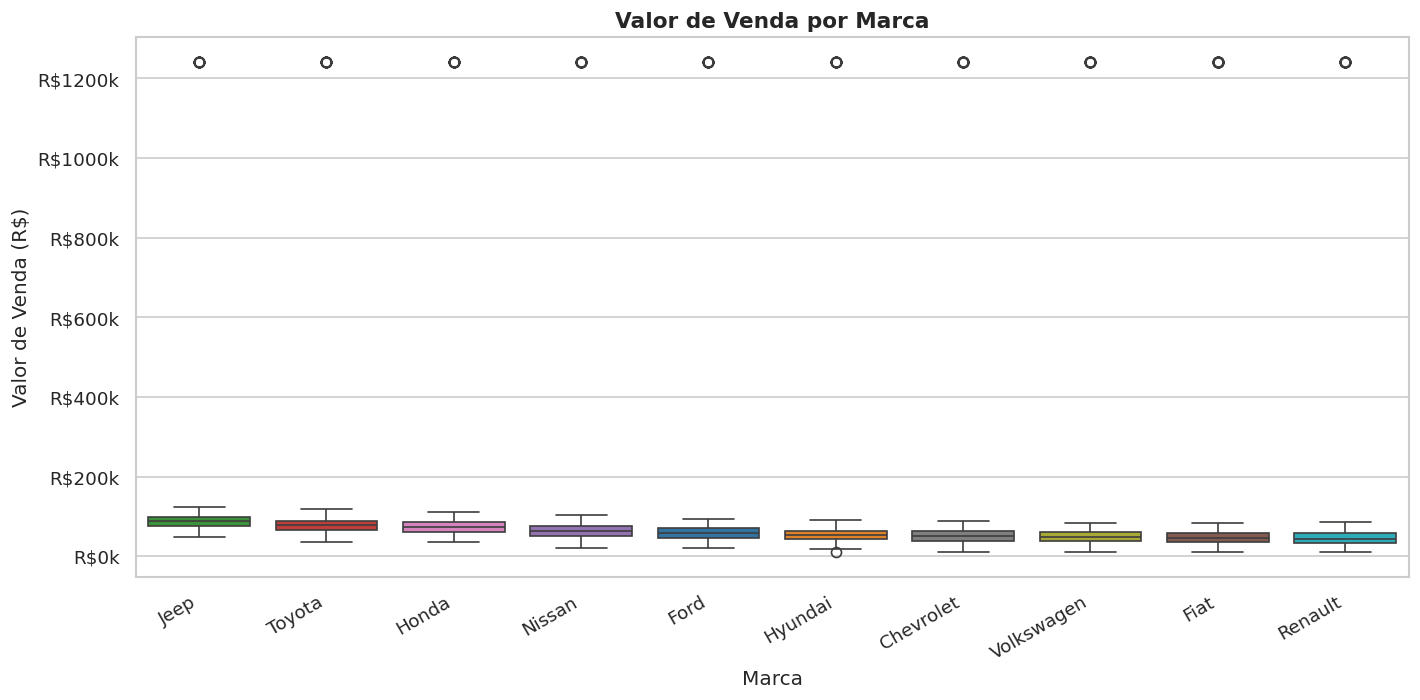

In [8]:
# ── Gráfico 2: Valor por Marca ────────────────────────────────────
ordem_marca = (
    df_raw.groupby('Marca')['Valor_Venda']
    .median().sort_values(ascending=False).index
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_raw, x='Marca', y='Valor_Venda', order=ordem_marca,
            ax=ax, hue='Marca', palette='tab10', legend=False)
ax.set_title('Valor de Venda por Marca', fontsize=13, fontweight='bold')
ax.set_xlabel('Marca')
ax.set_ylabel('Valor de Venda (R$)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('eda_outputs/02_valor_por_marca.png')
plt.show()

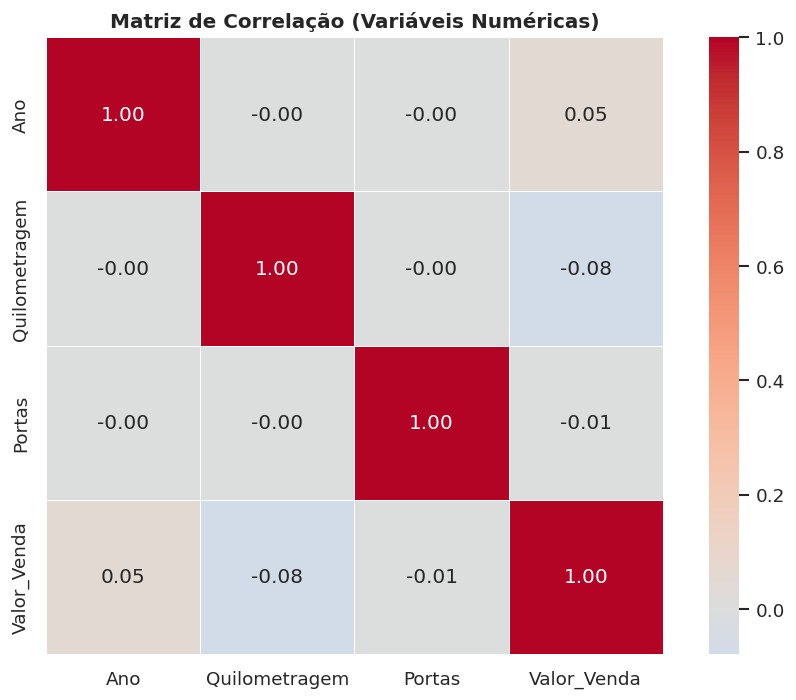

In [9]:
# ── Gráfico 3: Matriz de Correlação ──────────────────────────────
df_num = df_raw.copy()
df_num['Quilometragem'] = pd.to_numeric(df_num['Quilometragem'], errors='coerce')
num_cols_corr = df_num.select_dtypes(include=np.number).columns.tolist()
corr = df_num[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, linewidths=0.5, square=True)
ax.set_title('Matriz de Correlação (Variáveis Numéricas)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_outputs/03_correlacao.png')
plt.show()

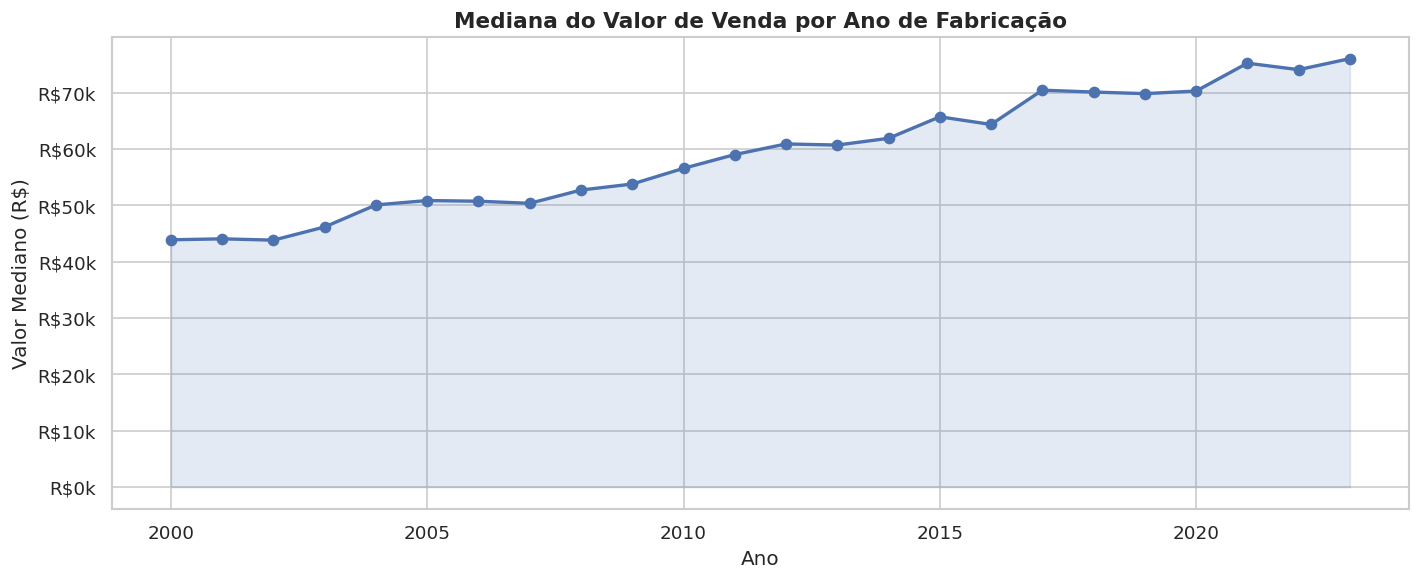

In [10]:
# ── Gráfico 4: Valor mediano por Ano ─────────────────────────────
df_limpo = df_raw.dropna(subset=['Ano'])
media_ano = df_limpo.groupby('Ano')['Valor_Venda'].median().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(media_ano['Ano'], media_ano['Valor_Venda'], marker='o', color='#4C72B0', linewidth=2)
ax.fill_between(media_ano['Ano'], media_ano['Valor_Venda'], alpha=0.15, color='#4C72B0')
ax.set_title('Mediana do Valor de Venda por Ano de Fabricação', fontsize=13, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Valor Mediano (R$)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('eda_outputs/04_valor_vs_ano.png')
plt.show()

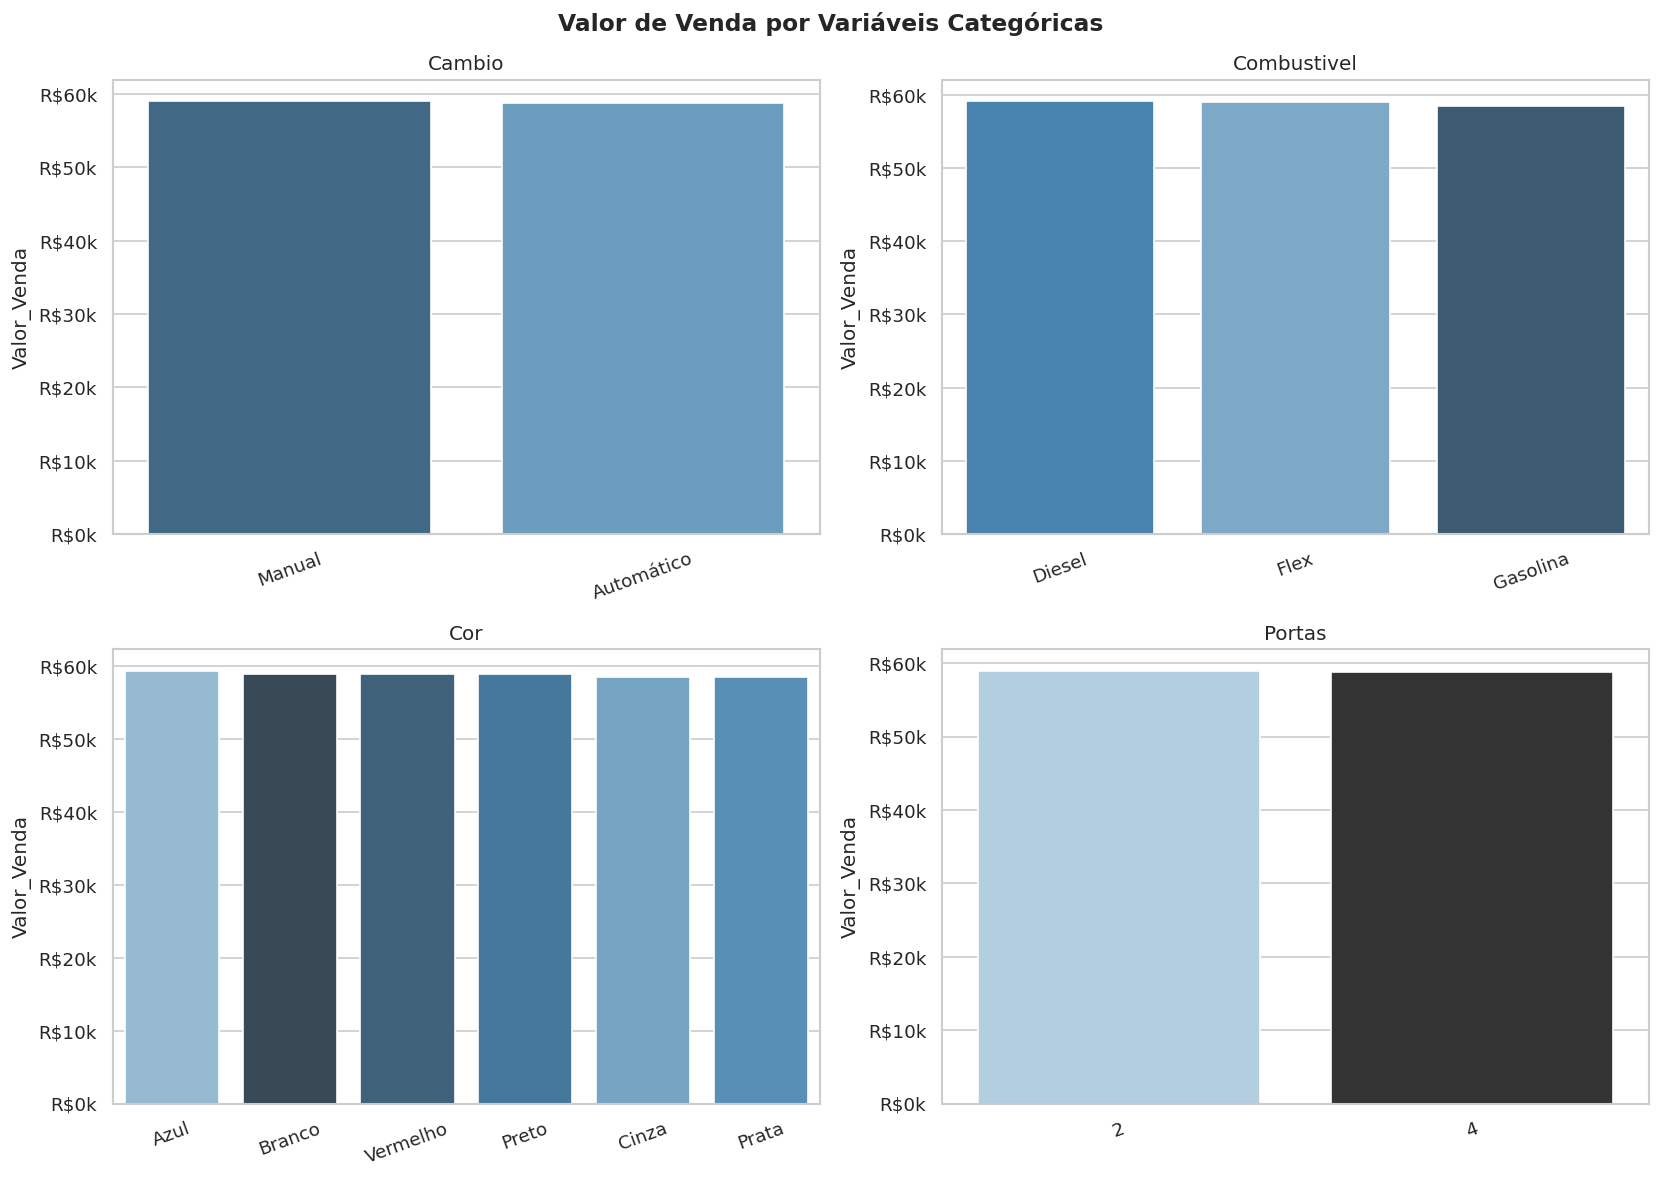

In [11]:
# ── Gráfico 5: Variáveis Categóricas ─────────────────────────────
cat_plot_cols = ['Cambio', 'Combustivel', 'Cor', 'Portas']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Valor de Venda por Variáveis Categóricas', fontsize=14, fontweight='bold')

for ax, col in zip(axes.flatten(), cat_plot_cols):
    ordem = (
        df_raw.groupby(col)['Valor_Venda'].median()
        .sort_values(ascending=False).index
    )
    sns.barplot(data=df_raw, x=col, y='Valor_Venda', order=ordem, ax=ax,
                estimator='median', errorbar=None, hue=col, palette='Blues_d', legend=False)
    ax.set_title(f'{col}')
    ax.set_xlabel('')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('eda_outputs/05_categoricas.png')
plt.show()

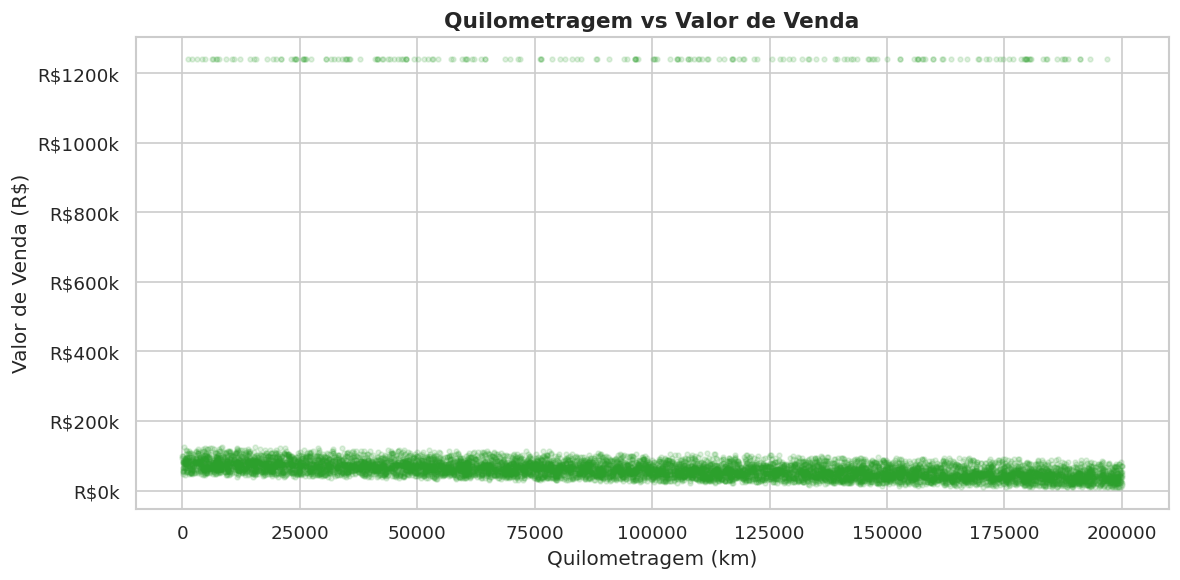

In [12]:
# ── Gráfico 6: Quilometragem vs Valor ────────────────────────────
df_km = df_raw.copy()
df_km['Quilometragem'] = pd.to_numeric(df_km['Quilometragem'], errors='coerce')

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df_km['Quilometragem'], df_km['Valor_Venda'],
           alpha=0.15, s=8, color='#2ca02c')
ax.set_title('Quilometragem vs Valor de Venda', fontsize=13, fontweight='bold')
ax.set_xlabel('Quilometragem (km)')
ax.set_ylabel('Valor de Venda (R$)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
plt.tight_layout()
plt.savefig('eda_outputs/06_quilometragem_vs_valor.png')
plt.show()

### 2.3 Insights da EDA

| # | Insight |
|---|---|
| 1 | A distribuição de `Valor_Venda` é **fortemente assimétrica à direita** — há outliers acima de R$500k |
| 2 | Após transformação log, a distribuição se aproxima de uma normal |
| 3 | Veículos mais novos (pós-2015) valem consideravelmente mais |
| 4 | Câmbio **automático** tem mediana de preço maior que manual |
| 5 | A correlação entre `Quilometragem` e `Valor_Venda` é **negativa** |
| 6 | `Ano` tem 100 valores nulos (1%) → imputação com mediana |
| 7 | Marcas premium (Jeep, Toyota) têm valores medianos mais altos |

---
## 3. Fase 3: Preparação dos Dados

In [13]:
# ── 3.1 Cópia e Correção de Tipos ───────────────────────────────
df = df_raw.copy()

# Quilometragem pode vir como string em alguns datasets
df['Quilometragem'] = pd.to_numeric(df['Quilometragem'], errors='coerce')

print('Tipos após conversão:')
print(df.dtypes)

Tipos após conversão:
Marca             object
Modelo            object
Ano              float64
Quilometragem    float64
Cor               object
Cambio            object
Combustivel       object
Portas             int64
Valor_Venda      float64
dtype: object


In [14]:
# ── 3.2 Imputação de Valores Ausentes ───────────────────────────
print(f'Nulos em Ano ANTES: {df["Ano"].isnull().sum()}')

df['Ano'] = df['Ano'].fillna(df['Ano'].median())

print(f'Nulos em Ano APÓS:  {df["Ano"].isnull().sum()}')

Nulos em Ano ANTES: 100
Nulos em Ano APÓS:  0


In [15]:
# ── 3.3 Feature Engineering ──────────────────────────────────────
ANO_REFERENCIA = 2024

df['Idade_Veiculo'] = ANO_REFERENCIA - df['Ano']
df['Km_por_Ano']    = df['Quilometragem'] / (df['Idade_Veiculo'].replace(0, 1))

print('Novas features criadas:')
print(df[['Ano', 'Quilometragem', 'Idade_Veiculo', 'Km_por_Ano']].describe().T)

Novas features criadas:
                 count          mean           std     min       25%  \
Ano            10000.0   2011.520900      6.869431  2000.0   2006.00   
Quilometragem   9900.0  99805.339798  57760.423897    10.0  50712.75   
Idade_Veiculo  10000.0     12.479100      6.869431     1.0      7.00   
Km_por_Ano      9900.0  15501.138224  25104.885862     2.0   4018.00   

                        50%            75%       max  
Ano             2012.000000    2017.000000    2023.0  
Quilometragem  99751.000000  149429.750000  199994.0  
Idade_Veiculo     12.000000      18.000000      24.0  
Km_por_Ano      8018.093434   15193.778846  199640.0  


In [16]:
# ── 3.4 Remoção de Outliers Extremos no Alvo ─────────────────────
q1 = df['Valor_Venda'].quantile(0.25)
q3 = df['Valor_Venda'].quantile(0.75)
iqr = q3 - q1
limite_sup = q3 + 3 * iqr

print(f'Q1 = R${q1:,.0f}  |  Q3 = R${q3:,.0f}  |  IQR = R${iqr:,.0f}')
print(f'Limite superior (3×IQR): R${limite_sup:,.0f}')
print(f'Registros removidos como outliers: {(df["Valor_Venda"] > limite_sup).sum()}')

df = df[df['Valor_Venda'] <= limite_sup].copy()
print(f'Registros restantes: {len(df):,}')

Q1 = R$44,467  |  Q3 = R$74,804  |  IQR = R$30,337
Limite superior (3×IQR): R$165,816
Registros removidos como outliers: 200
Registros restantes: 9,800


In [17]:
# ── 3.5 Definir Features e Target ────────────────────────────────
TARGET   = 'Valor_Venda'
CAT_COLS = ['Marca', 'Modelo', 'Cor', 'Cambio', 'Combustivel']
NUM_COLS = ['Ano', 'Quilometragem', 'Portas', 'Idade_Veiculo', 'Km_por_Ano']
FEATURES = CAT_COLS + NUM_COLS

X = df[FEATURES]
y = df[TARGET]

print(f'X: {X.shape}  |  y: {y.shape}')
print(f'Features categóricas: {CAT_COLS}')
print(f'Features numéricas:   {NUM_COLS}')

X: (9800, 10)  |  y: (9800,)
Features categóricas: ['Marca', 'Modelo', 'Cor', 'Cambio', 'Combustivel']
Features numéricas:   ['Ano', 'Quilometragem', 'Portas', 'Idade_Veiculo', 'Km_por_Ano']


In [18]:
# ── 3.6 Divisão Treino / Teste ───────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Treino: {X_train.shape[0]:,} amostras ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Teste:  {X_test.shape[0]:,} amostras ({X_test.shape[0]/len(X)*100:.0f}%)')

Treino: 7,840 amostras (80%)
Teste:  1,960 amostras (20%)


In [19]:
# ── 3.7 Pipeline de Pré-processamento ───────────────────────────
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown='use_encoded_value', unknown_value=-1
    )),
])

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

preprocessor = ColumnTransformer([
    ('cat', cat_pipeline, CAT_COLS),
    ('num', num_pipeline, NUM_COLS),
])

print('Pipeline de pré-processamento configurado:')
print('  - Categóricas → SimpleImputer (moda) → OrdinalEncoder')
print('  - Numéricas   → SimpleImputer (mediana) → StandardScaler')

Pipeline de pré-processamento configurado:
  - Categóricas → SimpleImputer (moda) → OrdinalEncoder
  - Numéricas   → SimpleImputer (mediana) → StandardScaler


---
## 4. Fase 4 & 5: Modelagem, Avaliação e MLflow

In [20]:
# ── 4.1 Definir modelos candidatos ───────────────────────────────
MODELS = {
    'Ridge': Ridge(alpha=10.0),
    'Lasso': Lasso(alpha=10.0),
    'RandomForest': RandomForestRegressor(
        n_estimators=200, max_depth=12, min_samples_leaf=3,
        n_jobs=-1, random_state=42
    ),
    'ExtraTrees': ExtraTreesRegressor(
        n_estimators=200, max_depth=12,
        n_jobs=-1, random_state=42
    ),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, random_state=42
    ),
    'XGBoost': XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=42, verbosity=0
    ),
    'LightGBM': LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.8,
        n_jobs=-1, random_state=42, verbose=-1
    ),
}

print(f'Total de modelos a comparar: {len(MODELS)}')
for nome in MODELS:
    print(f'  · {nome}')

Total de modelos a comparar: 7
  · Ridge
  · Lasso
  · RandomForest
  · ExtraTrees
  · GradientBoosting
  · XGBoost
  · LightGBM


In [21]:
# ── 4.2 Função de métricas ───────────────────────────────────────
def evaluate(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

print('Função de avaliação definida: MAE, RMSE, R², MAPE')

Função de avaliação definida: MAE, RMSE, R², MAPE


In [22]:
# ── 4.3 Treinamento, Cross-Validation e Registro MLflow ──────────
mlflow.set_tracking_uri('mlruns')
mlflow.set_experiment('car_price_brazil')

results     = {}
pipelines   = {}
best_name   = None
best_r2     = -np.inf
best_pipe   = None

print('🚀 Iniciando treinamento e registro MLflow...\n')
print(f'{"Modelo":<22} {"R²":>8} {"MAE (R$)":>12} {"RMSE (R$)":>13} {"MAPE%":>8} {"CV R²":>10}')
print('-' * 80)

for name, model in MODELS.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model',        model),
    ])

    # Cross-validation no conjunto de treino
    cv_scores = cross_val_score(
        pipe, X_train, y_train, cv=3, scoring='r2', n_jobs=-1
    )

    # Treino final
    pipe.fit(X_train, y_train)
    y_pred  = pipe.predict(X_test)
    metrics = evaluate(y_test.values, y_pred)
    metrics['CV_R2_mean'] = cv_scores.mean()
    metrics['CV_R2_std']  = cv_scores.std()

    results[name]   = metrics
    pipelines[name] = pipe

    # Registro MLflow
    with mlflow.start_run(run_name=name):
        mlflow.log_params({
            'model'     : name,
            'test_size' : 0.2,
            'cv_folds'  : 3,
        })
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(pipe, artifact_path='model')

    print(
        f'{name:<22} '
        f'{metrics["R2"]:>8.4f} '
        f'{metrics["MAE"]:>12,.0f} '
        f'{metrics["RMSE"]:>13,.0f} '
        f'{metrics["MAPE"]:>8.2f} '
        f'{metrics["CV_R2_mean"]:>8.4f}±{metrics["CV_R2_std"]:.4f}'
    )

    if metrics['R2'] > best_r2:
        best_r2, best_name, best_pipe = metrics['R2'], name, pipe

print('-' * 80)
print(f'\n🏆 Melhor modelo: {best_name}  (R² = {best_r2:.4f})')

2026/03/22 18:30:47 INFO mlflow.tracking.fluent: Experiment with name 'car_price_brazil' does not exist. Creating a new experiment.


🚀 Iniciando treinamento e registro MLflow...

Modelo                       R²     MAE (R$)     RMSE (R$)    MAPE%      CV R²
--------------------------------------------------------------------------------


2026/03/22 18:30:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 18:30:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/22 18:31:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Ridge                    0.5749       11,488        13,893    22.23   0.5561±0.0163


2026/03/22 18:31:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

GradientBoosting         0.9726        2,858         3,527     5.71   0.9701±0.0005


2026/03/22 18:32:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 18:32:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


XGBoost                  0.9727        2,853         3,523     5.70   0.9703±0.0007


2026/03/22 18:32:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/22 18:32:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


LightGBM                 0.9725        2,844         3,533     5.69   0.9699±0.0005
--------------------------------------------------------------------------------

🏆 Melhor modelo: XGBoost  (R² = 0.9727)


In [23]:
# ── 4.4 Tabela-ranking dos modelos ───────────────────────────────
df_res = pd.DataFrame(results).T
df_res = df_res[['R2', 'MAE', 'RMSE', 'MAPE', 'CV_R2_mean', 'CV_R2_std']]
df_res = df_res.sort_values('R2', ascending=False)
df_res.index.name = 'Modelo'

display(
    df_res.style
    .format({'R2': '{:.4f}', 'MAE': 'R${:,.0f}', 'RMSE': 'R${:,.0f}',
             'MAPE': '{:.2f}%', 'CV_R2_mean': '{:.4f}', 'CV_R2_std': '{:.4f}'})
    .background_gradient(subset=['R2'],  cmap='Greens')
    .background_gradient(subset=['MAE'], cmap='Reds_r')
    .highlight_max(subset=['R2'],  color='#d4edda')
    .highlight_min(subset=['MAE'], color='#d4edda')
)

,R2,MAE,RMSE,MAPE,CV_R2_mean,CV_R2_std
Modelo,,,,,,
XGBoost,0.9727,"R$2,853","R$3,523",5.70%,0.9703,0.0007
GradientBoosting,0.9726,"R$2,858","R$3,527",5.71%,0.9701,0.0005
LightGBM,0.9725,"R$2,844","R$3,533",5.69%,0.9699,0.0005
ExtraTrees,0.9594,"R$3,372","R$4,293",6.72%,0.9534,0.0022
RandomForest,0.9594,"R$3,367","R$4,293",6.69%,0.9560,0.0012
Lasso,0.5749,"R$11,487","R$13,892",22.23%,0.5562,0.0163
Ridge,0.5749,"R$11,488","R$13,893",22.23%,0.5561,0.0163


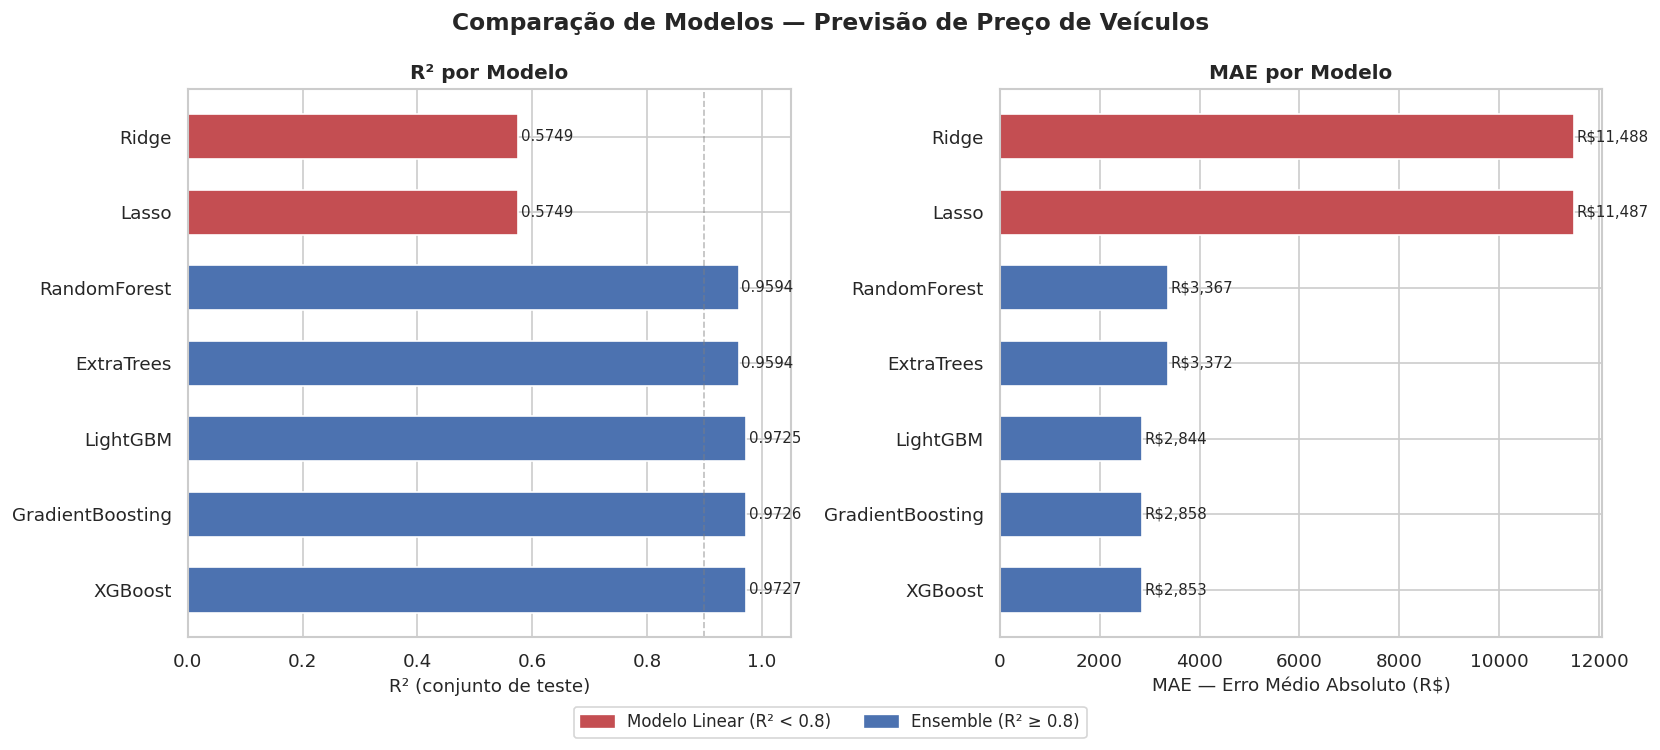

In [24]:
# ── 4.5 Gráfico de comparação dos modelos ────────────────────────
nomes   = df_res.index.tolist()
r2_vals = df_res['R2'].tolist()
mae_vals= df_res['MAE'].tolist()

cores = ['#c44e52' if r < 0.8 else '#4c72b0' for r in r2_vals]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Comparação de Modelos — Previsão de Preço de Veículos',
             fontsize=14, fontweight='bold')

bars = axes[0].barh(nomes, r2_vals, color=cores, edgecolor='white', height=0.6)
axes[0].set_xlabel('R² (conjunto de teste)', fontsize=11)
axes[0].set_title('R² por Modelo', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 1.05)
axes[0].axvline(0.9, color='gray', linestyle='--', alpha=0.5, linewidth=1)
for bar, val in zip(bars, r2_vals):
    axes[0].text(val + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center', fontsize=9)

bars2 = axes[1].barh(nomes, mae_vals, color=cores, edgecolor='white', height=0.6)
axes[1].set_xlabel('MAE — Erro Médio Absoluto (R$)', fontsize=11)
axes[1].set_title('MAE por Modelo', fontsize=12, fontweight='bold')
for bar, val in zip(bars2, mae_vals):
    axes[1].text(val + 50, bar.get_y() + bar.get_height()/2,
                 f'R${val:,.0f}', va='center', fontsize=9)

patches = [
    mpatches.Patch(color='#c44e52', label='Modelo Linear (R² < 0.8)'),
    mpatches.Patch(color='#4c72b0', label='Ensemble (R² ≥ 0.8)'),
]
fig.legend(handles=patches, loc='lower center', ncol=2,
           fontsize=10, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('eda_outputs/07_comparacao_modelos.png', bbox_inches='tight')
plt.show()

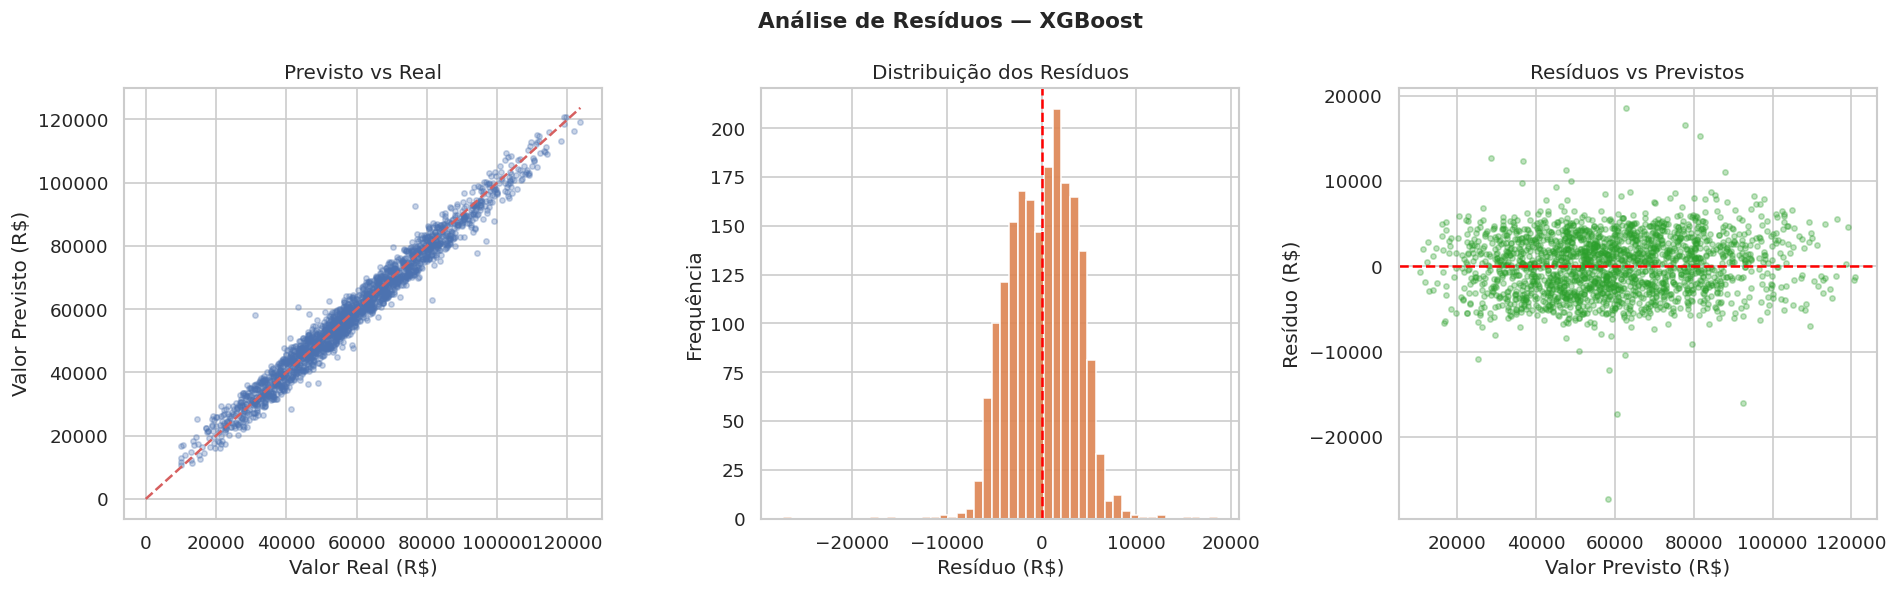

Resíduo médio:    R$199.27
Desvio padrão:    R$3,517.83


In [25]:
# ── 4.6 Análise de Resíduos do Melhor Modelo ─────────────────────
y_pred_best = best_pipe.predict(X_test)
residuos    = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Análise de Resíduos — {best_name}', fontsize=13, fontweight='bold')

# Previsto vs Real
axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=10, color='#4C72B0')
lim = max(y_test.max(), y_pred_best.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=1.5)
axes[0].set_xlabel('Valor Real (R$)')
axes[0].set_ylabel('Valor Previsto (R$)')
axes[0].set_title('Previsto vs Real')

# Distribuição dos Resíduos
axes[1].hist(residuos, bins=50, color='#DD8452', edgecolor='white', alpha=0.9)
axes[1].axvline(0, color='red', linewidth=1.5, linestyle='--')
axes[1].set_xlabel('Resíduo (R$)')
axes[1].set_ylabel('Frequência')
axes[1].set_title('Distribuição dos Resíduos')

# Resíduos vs Previstos
axes[2].scatter(y_pred_best, residuos, alpha=0.3, s=10, color='#2ca02c')
axes[2].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[2].set_xlabel('Valor Previsto (R$)')
axes[2].set_ylabel('Resíduo (R$)')
axes[2].set_title('Resíduos vs Previstos')

plt.tight_layout()
plt.savefig('eda_outputs/08_residuos.png')
plt.show()

print(f'Resíduo médio:    R${residuos.mean():,.2f}')
print(f'Desvio padrão:    R${residuos.std():,.2f}')

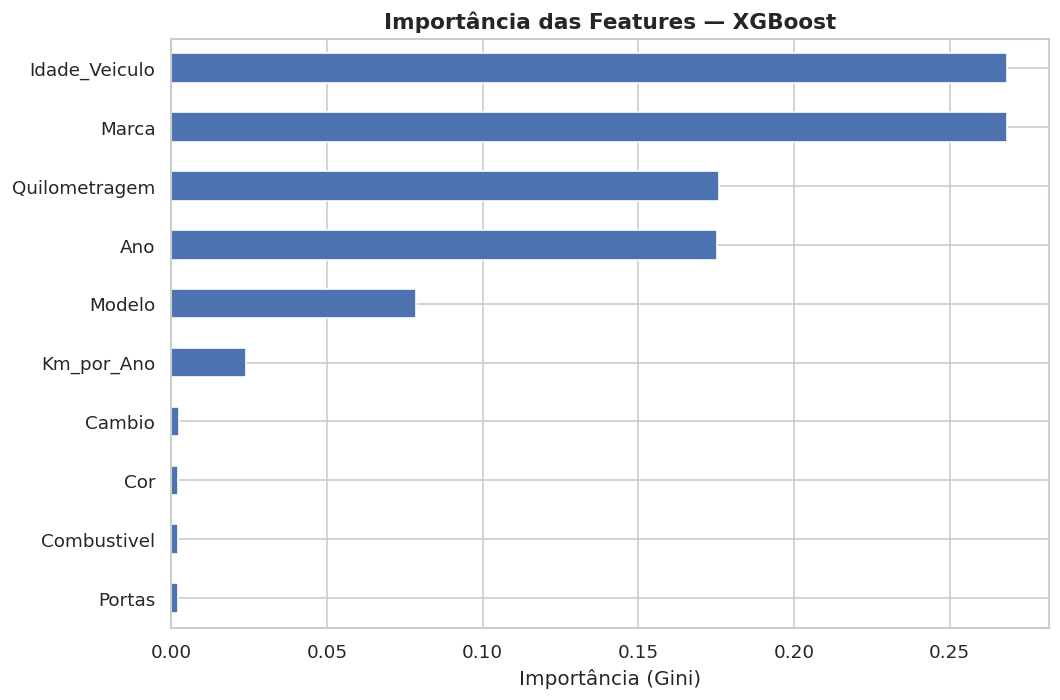

In [26]:
# ── 4.7 Importância das Features (melhor modelo, se suportar) ────
feature_names = CAT_COLS + NUM_COLS

try:
    importances = best_pipe.named_steps['model'].feature_importances_
    fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 6))
    fi.plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
    ax.set_title(f'Importância das Features — {best_name}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Importância (Gini)')
    plt.tight_layout()
    plt.savefig('eda_outputs/09_feature_importance.png')
    plt.show()
except AttributeError:
    print(f'O modelo {best_name} não expõe feature_importances_.')

---
## 5. Fase 5: Salvar o Melhor Modelo

In [27]:
# ── 5.1 Salvar pipeline completo ────────────────────────────────
model_path = 'models/best_model.pkl'
joblib.dump(best_pipe, model_path)
print(f' Modelo salvo em: {model_path}')

# Verificar tamanho do arquivo
size_mb = os.path.getsize(model_path) / 1024**2
print(f'   Tamanho: {size_mb:.1f} MB')

 Modelo salvo em: models/best_model.pkl
   Tamanho: 1.3 MB


In [28]:
# ── 5.2 Salvar metadados para o app de deploy ────────────────────
meta = {
    'best_model'  : best_name,
    'r2'          : round(results[best_name]['R2'], 4),
    'mae'         : round(results[best_name]['MAE'], 2),
    'rmse'        : round(results[best_name]['RMSE'], 2),
    'features'    : FEATURES,
    'marcas'      : sorted(df['Marca'].unique().tolist()),
    'modelos'     : {
        k: sorted(v.tolist())
        for k, v in df.groupby('Marca')['Modelo'].unique().items()
    },
    'cores'       : sorted(df['Cor'].unique().tolist()),
    'cambios'     : sorted(df['Cambio'].unique().tolist()),
    'combustiveis': sorted(df['Combustivel'].unique().tolist()),
    'ano_min'     : int(df['Ano'].min()),
    'ano_max'     : int(df['Ano'].max()),
    'km_min'      : int(df['Quilometragem'].min()),
    'km_max'      : int(df['Quilometragem'].max()),
}

meta_path = 'models/metadata.json'
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print(f' Metadados salvos em: {meta_path}')
print(json.dumps({k: v for k, v in meta.items() if k != 'modelos'}, indent=2, ensure_ascii=False))

 Metadados salvos em: models/metadata.json
{
  "best_model": "XGBoost",
  "r2": 0.9727,
  "mae": 2853.18,
  "rmse": 3523.47,
  "features": [
    "Marca",
    "Modelo",
    "Cor",
    "Cambio",
    "Combustivel",
    "Ano",
    "Quilometragem",
    "Portas",
    "Idade_Veiculo",
    "Km_por_Ano"
  ],
  "marcas": [
    "Chevrolet",
    "Fiat",
    "Ford",
    "Honda",
    "Hyundai",
    "Jeep",
    "Nissan",
    "Renault",
    "Toyota",
    "Volkswagen"
  ],
  "cores": [
    "Azul",
    "Branco",
    "Cinza",
    "Prata",
    "Preto",
    "Vermelho"
  ],
  "cambios": [
    "Automático",
    "Manual"
  ],
  "combustiveis": [
    "Diesel",
    "Flex",
    "Gasolina"
  ],
  "ano_min": 2000,
  "ano_max": 2023,
  "km_min": 10,
  "km_max": 199994
}


In [29]:
# ── 5.3 Testar o modelo carregado ───────────────────────────────
modelo_carregado = joblib.load(model_path)

exemplo = pd.DataFrame([{
    'Marca'        : 'Toyota',
    'Modelo'       : 'Corolla',
    'Ano'          : 2019,
    'Quilometragem': 45000,
    'Cor'          : 'Prata',
    'Cambio'       : 'Automático',
    'Combustivel'  : 'Flex',
    'Portas'       : 4,
    'Idade_Veiculo': 2024 - 2019,
    'Km_por_Ano'   : 45000 / 5,
}])

preco_previsto = modelo_carregado.predict(exemplo)[0]
print(f' Toyota Corolla 2019 — 45.000 km — Automático — Flex')
print(f'    Preço previsto: R$ {preco_previsto:,.2f}')
print(f'    Faixa estimada: R${preco_previsto*0.92:,.0f} — R${preco_previsto*1.08:,.0f}')

 Toyota Corolla 2019 — 45.000 km — Automático — Flex
    Preço previsto: R$ 98,019.39
    Faixa estimada: R$90,178 — R$105,861


---
## 6. MLflow — Visualizar Experimentos

Para abrir a interface do MLflow no navegador, execute no terminal:

```bash
mlflow ui --backend-store-uri mlruns/
```

Depois acesse: **http://localhost:5000**

Na interface você verá:
- Todos os experimentos registrados
- Métricas de cada modelo (R², MAE, RMSE, MAPE)
- Os parâmetros usados
- Os artefatos (modelos salvos)

In [30]:
# Ver experimentos via API do MLflow
experimento = mlflow.get_experiment_by_name('car_price_brazil')
runs = mlflow.search_runs(experiment_ids=[experimento.experiment_id])

colunas = ['tags.mlflow.runName', 'metrics.R2', 'metrics.MAE', 'metrics.RMSE', 'metrics.MAPE']
colunas = [c for c in colunas if c in runs.columns]

display(
    runs[colunas]
    .rename(columns={'tags.mlflow.runName': 'Modelo'})
    .sort_values('metrics.R2', ascending=False)
    .reset_index(drop=True)
)

,Modelo,metrics.R2,metrics.MAE,metrics.RMSE,metrics.MAPE
0,XGBoost,0.972655,2853.180051,3523.469845,5.703496
1,GradientBoosting,0.972602,2858.491007,3526.875817,5.707251
2,LightGBM,0.972510,2844.249954,3532.776561,5.694781
3,ExtraTrees,0.959413,3371.742527,4292.645660,6.720867
4,RandomForest,0.959402,3367.033984,4293.234112,6.688112
5,Lasso,0.574941,11487.161908,13891.730657,22.230145
6,Ridge,0.574850,11487.574063,13893.213764,22.231623


---
## 7. Fase 6: Deploy (Hugging Face Spaces)

O arquivo `app.py` abaixo deve ser usado junto com `models/best_model.pkl` e `models/metadata.json` para publicar no **Hugging Face Spaces**.

### Passo a passo do deploy:
1. Crie uma conta em [huggingface.co](https://huggingface.co)
2. Crie um novo Space: **New Space → Gradio → Python 3.10**
3. Faça upload de:
   - `app.py`
   - `requirements.txt`
   - Pasta `models/` (com `best_model.pkl` e `metadata.json`)
4. O deploy é feito automaticamente ✅

In [31]:
# ── Gerar app.py para deploy ─────────────────────────────────────
app_code = '''
"""
Aplicação Web – Previsão de Preço de Veículos no Brasil
Deploy: Hugging Face Spaces (Gradio)

 Este conteúdo é destinado apenas para fins educacionais.
   Os dados exibidos são ilustrativos e podem não corresponder a situações reais.
"""

import os, json, joblib
import numpy as np
import pandas as pd
import gradio as gr

model    = joblib.load('models/best_model.pkl')
with open('models/metadata.json') as f:
    meta = json.load(f)

MARCAS           = meta['marcas']
MODELOS_POR_MARCA = meta['modelos']
CORES            = meta['cores']
CAMBIOS          = meta['cambios']
COMBUSTIVEIS     = meta['combustiveis']
ANO_MIN          = meta['ano_min']
ANO_MAX          = meta['ano_max']
KM_MIN           = meta['km_min']
KM_MAX           = meta['km_max']
BEST_MODEL_NAME  = meta['best_model']
BEST_R2          = meta['r2']
BEST_MAE         = meta['mae']

def get_modelos(marca):
    modelos = MODELOS_POR_MARCA.get(marca, [])
    return gr.Dropdown(choices=modelos, value=modelos[0] if modelos else None)

def predict(marca, modelo, ano, quilometragem, cor, cambio, combustivel, portas):
    try:
        ano, quilometragem, portas = int(ano), int(quilometragem), int(portas)
        idade     = 2024 - ano
        km_por_ano = quilometragem / max(idade, 1)
        row = pd.DataFrame([{
            'Marca': marca, 'Modelo': modelo, 'Ano': ano,
            'Quilometragem': quilometragem, 'Cor': cor,
            'Cambio': cambio, 'Combustivel': combustivel, 'Portas': portas,
            'Idade_Veiculo': idade, 'Km_por_Ano': km_por_ano,
        }])
        preco = max(model.predict(row)[0], 0)
        return (
            f" **R$ {preco:,.2f}**",
            f" Faixa estimada: R$ {preco*0.92:,.0f} — R$ {preco*1.08:,.0f}",
        )
    except Exception as e:
        return f" Erro: {e}", ""

DESCRICAO = f"""
##  Previsão de Preço de Veículos Usados no Brasil

>  **Este conteúdo é destinado apenas para fins educacionais. Os dados exibidos são ilustrativos e podem não corresponder a situações reais.**

**Modelo:** `{BEST_MODEL_NAME}` — R² = `{BEST_R2}` | MAE = R$ `{BEST_MAE:,.0f}`
"""

with gr.Blocks(title="Previsão de Preço de Veículos BR", theme=gr.themes.Soft()) as demo:
    gr.Markdown(DESCRICAO)
    with gr.Row():
        with gr.Column():
            marca      = gr.Dropdown(choices=MARCAS, value=MARCAS[0], label="Marca")
            modelo_dd  = gr.Dropdown(choices=MODELOS_POR_MARCA[MARCAS[0]],
                                     value=MODELOS_POR_MARCA[MARCAS[0]][0], label="Modelo")
            marca.change(fn=get_modelos, inputs=marca, outputs=modelo_dd)
            ano        = gr.Slider(ANO_MIN, ANO_MAX, value=2015, step=1, label="Ano")
            km         = gr.Slider(KM_MIN, KM_MAX, value=60000, step=1000, label="Quilometragem (km)")
            cambio     = gr.Radio(choices=CAMBIOS, value=CAMBIOS[0], label="Câmbio")
            combustivel= gr.Dropdown(choices=COMBUSTIVEIS, value=COMBUSTIVEIS[0], label="Combustível")
            cor        = gr.Dropdown(choices=CORES, value=CORES[0], label="Cor")
            portas     = gr.Radio(choices=["2","4"], value="4", label="Portas")
            btn        = gr.Button(" Prever Preço", variant="primary")
        with gr.Column():
            out_preco = gr.Markdown()
            out_faixa = gr.Markdown()
    btn.click(fn=predict,
              inputs=[marca, modelo_dd, ano, km, cor, cambio, combustivel, portas],
              outputs=[out_preco, out_faixa])
    gr.Markdown("---\n>  *Este conteúdo é destinado apenas para fins educacionais. Os dados exibidos são ilustrativos e podem não corresponder a situações reais.*")

if __name__ == "__main__":
    demo.launch()
'''

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code.strip())

print(' app.py gerado com sucesso!')

 app.py gerado com sucesso!


In [32]:
# ── Gerar requirements.txt ────────────────────────────────────────
reqs = """pandas==2.1.4
numpy==1.26.4
scikit-learn==1.4.2
xgboost==2.0.3
lightgbm==4.3.0
mlflow==2.12.1
matplotlib==3.8.4
seaborn==0.13.2
gradio==4.31.0
joblib==1.4.0
"""

with open('requirements.txt', 'w') as f:
    f.write(reqs)

print(' requirements.txt gerado!')

 requirements.txt gerado!


---
## 8. Resumo Final do Projeto

###  Resultados

In [33]:
print('          RESUMO FINAL DO PROJETO')

print(f'\n Dataset:    10.000 registros, 9 variáveis')
print(f' Features:   {len(FEATURES)} ({len(CAT_COLS)} cat + {len(NUM_COLS)} num)')
print(f' Outliers:   {10000 - len(df)} registros removidos (>Q3+3×IQR)')
print(f' Divisão:    80% treino / 20% teste')
print(f' Modelos:    {len(MODELS)} algoritmos comparados')
print(f'\n MELHOR MODELO: {best_name}')
print(f'   R²   = {results[best_name]["R2"]:.4f}')
print(f'   MAE  = R$ {results[best_name]["MAE"]:,.2f}')
print(f'   RMSE = R$ {results[best_name]["RMSE"]:,.2f}')
print(f'   MAPE = {results[best_name]["MAPE"]:.2f}%')
print(f'   CV R²= {results[best_name]["CV_R2_mean"]:.4f} ± {results[best_name]["CV_R2_std"]:.4f}')
print(f'\n Arquivos gerados:')
for f in ['models/best_model.pkl', 'models/metadata.json', 'app.py', 'requirements.txt']:
    existe = '' if os.path.exists(f) else ''
    print(f'   {existe} {f}')
print(f'\n Gráficos EDA:')
for g in sorted(os.listdir('eda_outputs')):
    print(f'    eda_outputs/{g}')
print(f'\n MLflow: mlflow ui --backend-store-uri mlruns/')
print(f' Deploy: Hugging Face Spaces (app.py + models/)')

print('  Conteúdo para fins educacionais. Dados ilustrativos.')

          RESUMO FINAL DO PROJETO

 Dataset:    10.000 registros, 9 variáveis
 Features:   10 (5 cat + 5 num)
 Outliers:   200 registros removidos (>Q3+3×IQR)
 Divisão:    80% treino / 20% teste
 Modelos:    7 algoritmos comparados

 MELHOR MODELO: XGBoost
   R²   = 0.9727
   MAE  = R$ 2,853.18
   RMSE = R$ 3,523.47
   MAPE = 5.70%
   CV R²= 0.9703 ± 0.0007

 Arquivos gerados:
    models/best_model.pkl
    models/metadata.json
    app.py
    requirements.txt

 Gráficos EDA:
    eda_outputs/01_distribuicao_alvo.png
    eda_outputs/02_valor_por_marca.png
    eda_outputs/03_correlacao.png
    eda_outputs/04_valor_vs_ano.png
    eda_outputs/05_categoricas.png
    eda_outputs/06_quilometragem_vs_valor.png
    eda_outputs/07_comparacao_modelos.png
    eda_outputs/08_residuos.png
    eda_outputs/09_feature_importance.png

 MLflow: mlflow ui --backend-store-uri mlruns/
 Deploy: Hugging Face Spaces (app.py + models/)
  Conteúdo para fins educacionais. Dados ilustrativos.


---

## 🗂️ Estrutura do Repositório GitHub

```
car-price-predictor-br/
├── car_price_predictor_br.ipynb   ← Este notebook
├── app.py                         ← Web app Gradio (deploy)
├── requirements.txt
├── README.md
├── data/
│   └── dataset_carros_brasil.csv
├── models/
│   ├── best_model.pkl
│   └── metadata.json
├── eda_outputs/                   ← Gráficos gerados
│   ├── 01_distribuicao_alvo.png
│   ├── 02_valor_por_marca.png
│   ├── 03_correlacao.png
│   ├── 04_valor_vs_ano.png
│   ├── 05_categoricas.png
│   ├── 06_quilometragem_vs_valor.png
│   ├── 07_comparacao_modelos.png
│   ├── 08_residuos.png
│   └── 09_feature_importance.png
└── mlruns/                        ← Experimentos MLflow
```

## 🚀 Como subir no GitHub

```bash
git init
git add .
git commit -m "feat: projeto ML previsão preço veículos CRISP-DM"
git remote add origin https://github.com/SEU_USUARIO/car-price-predictor-br.git
git push -u origin main
```

## 🌐 Deploy no Hugging Face Spaces

1. Acesse [huggingface.co/new-space](https://huggingface.co/new-space)
2. Escolha **Gradio** como SDK
3. Faça upload de: `app.py`, `requirements.txt`, pasta `models/`
4. Pronto! Seu link público estará disponível em segundos ✅

---

> ⚠️ **Este conteúdo é destinado apenas para fins educacionais. Os dados exibidos são ilustrativos e podem não corresponder a situações reais.**